# Balancing and Resampling in Python

This notebook implements practical techniques for handling imbalanced classification data.

- Inspect class imbalance
- Split train/test before balancing
- Compare undersampling, oversampling, hybrid sampling, ROSE-style synthetic sampling, SMOTE, and ADASYN
- Evaluate models using metrics that are more useful than accuracy alone
- Interpret the results in business and data mining terms

## 1. Libraries and setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Helper functions

Functions to keep the notebook readable:

- Class balance summaries
- Simple charts
- Train/test model evaluation
- Core resampling methods

In [20]:
def class_balance_table(y, label_name="target"):
    # Count each class and compute its percentage in the target vector.
    counts = pd.Series(y, name=label_name).value_counts().sort_index()
    return pd.DataFrame({
        "class": counts.index,
        "count": counts.values,
        "percent": (counts.values / counts.sum() * 100).round(2),
    })


def plot_class_balance(y, title="Class balance"):
    # Build a summary table and plot the class distribution as a bar chart.
    balance = class_balance_table(y)
    _, ax = plt.subplots()
    sns.barplot(data=balance, x="class", y="count", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of observations")
    for i, row in balance.iterrows():
        ax.text(i, row["count"], f'{row["percent"]:.1f}%', ha="center", va="bottom")
    plt.show()


def plot_2d_data(X, y, title="2D view"):
    # Convert the feature matrix into a DataFrame and plot the two classes in 2D.
    plot_df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
    plot_df["class"] = y
    _, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x="feature_1",
        y="feature_2",
        hue="class",
        alpha=0.75,
        ax=ax,
    )
    ax.set_title(title)
    plt.show()


def evaluate_classifier(model, X_train, y_train, X_test, y_test, label):
    # Fit the model on the training set and compute metrics on the untouched test set.
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Use probabilities when available; otherwise fall back to class predictions.
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    return {
        "model": label,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, zero_division=0),
    }


def print_evaluation(result):
    # Print the main evaluation metrics and the confusion matrix in a compact form.
    print(result["model"])
    print("-" * len(result["model"]))
    print(f"Accuracy : {result['accuracy']:.3f}")
    print(f"Precision: {result['precision']:.3f}")
    print(f"Recall   : {result['recall']:.3f}")
    print(f"F1-score : {result['f1']:.3f}")
    print(f"ROC AUC  : {result['roc_auc']:.3f}")
    print("\nConfusion matrix:")
    print(result["confusion_matrix"])


def metrics_frame(results):
    # Convert a list of evaluation dictionaries into a comparison table.
    return pd.DataFrame([
        {
            "model": r["model"],
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "roc_auc": r["roc_auc"],
        }
        for r in results
    ]).set_index("model").round(3)

In [21]:
def random_undersample(X, y, random_state=42):
    """Randomly undersample the majority class.

    This function is a simple balancing method for binary classification.
    It keeps all observations from the minority class and randomly removes
    observations from the majority class until both classes have the same size.

    This method reduces class imbalance by throwing away data from the larger class. 
    It is easy to understand and fast to apply, but it may discard potentially 
    useful information from the training set.

    Parameters
    ----------
    X : array-like
        Feature matrix.
    y : array-like
        Target labels.
    random_state : int, default=42
        Seed for reproducible random sampling.

    Returns
    -------
    X_resampled : numpy.ndarray
        Resampled feature matrix with balanced class counts.
    y_resampled : numpy.ndarray
        Resampled target array with balanced class counts.
    """
    rng = np.random.default_rng(random_state)
    X_df = pd.DataFrame(X).reset_index(drop=True)
    y_s = pd.Series(y).reset_index(drop=True)

    class_counts = y_s.value_counts()
    minority_class = class_counts.idxmin()
    majority_class = class_counts.idxmax()
    n_minority = class_counts.min()

    minority_idx = y_s[y_s == minority_class].index.to_numpy()
    majority_idx = y_s[y_s == majority_class].index.to_numpy()
    sampled_majority_idx = rng.choice(majority_idx, size=n_minority, replace=False)

    selected_idx = np.concatenate([minority_idx, sampled_majority_idx])
    rng.shuffle(selected_idx)

    return X_df.iloc[selected_idx].to_numpy(), y_s.iloc[selected_idx].to_numpy()


def random_oversample(X, y, random_state=42):
    """Randomly oversample the minority class.

    This function balances a binary dataset by duplicating existing minority
    class observations until the minority class reaches the same size as the
    majority class.

    This method increases the representation of the rare class without creating 
    new synthetic patterns. It can help the classifier pay more attention to 
    minority cases, but because it reuses the same rows, it may increase the 
    risk of overfitting.

    Parameters
    ----------
    X : array-like
        Feature matrix.
    y : array-like
        Target labels.
    random_state : int, default=42
        Seed for reproducible random sampling.

    Returns
    -------
    X_resampled : numpy.ndarray
        Feature matrix after adding duplicated minority samples.
    y_resampled : numpy.ndarray
        Target array after adding duplicated minority labels.
    """
    rng = np.random.default_rng(random_state)
    X_df = pd.DataFrame(X).reset_index(drop=True)
    y_s = pd.Series(y).reset_index(drop=True)

    class_counts = y_s.value_counts()
    minority_class = class_counts.idxmin()
    n_to_add = class_counts.max() - class_counts.min()

    minority_idx = y_s[y_s == minority_class].index.to_numpy()
    sampled_minority_idx = rng.choice(minority_idx, size=n_to_add, replace=True)

    X_new = pd.concat([X_df, X_df.iloc[sampled_minority_idx]], ignore_index=True)
    y_new = pd.concat([y_s, y_s.iloc[sampled_minority_idx]], ignore_index=True)

    shuffle_idx = rng.permutation(len(y_new))
    return X_new.iloc[shuffle_idx].to_numpy(), y_new.iloc[shuffle_idx].to_numpy()


def hybrid_sample(X, y, target_ratio=0.50, random_state=42):
    """Combine oversampling and undersampling to meet in the middle.

    This method balances the dataset by increasing the minority class and
    reducing the majority class toward a shared target size. With the default
    ``target_ratio=0.50``, the target size is the midpoint between the original
    minority and majority class counts.

    This hybrid approach avoids the extremes of pure undersampling and pure oversampling. 
    It keeps more information than strict undersampling while requiring fewer duplicated 
    or synthetic samples than full oversampling.

    Parameters
    ----------
    X : array-like
        Feature matrix.
    y : array-like
        Target labels.
    target_ratio : float, default=0.50
        Controls the target size for each class relative to the distance
        between minority and majority counts.
    random_state : int, default=42
        Seed for reproducible random sampling.

    Returns
    -------
    X_resampled : numpy.ndarray
        Resampled feature matrix with both classes moved toward a common size.
    y_resampled : numpy.ndarray
        Resampled target array.
    """
    rng = np.random.default_rng(random_state)
    X_df = pd.DataFrame(X).reset_index(drop=True)
    y_s = pd.Series(y).reset_index(drop=True)

    counts = y_s.value_counts()
    minority_class = counts.idxmin()
    majority_class = counts.idxmax()
    n_target_each = int((counts.min() + counts.max()) * target_ratio)

    minority_idx = y_s[y_s == minority_class].index.to_numpy()
    majority_idx = y_s[y_s == majority_class].index.to_numpy()

    sampled_minority_idx = rng.choice(minority_idx, size=n_target_each, replace=True)
    sampled_majority_idx = rng.choice(majority_idx, size=n_target_each, replace=False)

    selected_idx = np.concatenate([sampled_minority_idx, sampled_majority_idx])
    rng.shuffle(selected_idx)

    return X_df.iloc[selected_idx].to_numpy(), y_s.iloc[selected_idx].to_numpy()


def rose_style_sample(X, y, noise_scale=0.08, random_state=42):
    """Generate ROSE-style smoothed bootstrap samples for the minority class.

    This is a simplified version of the ROSE idea. Minority class
    observations are sampled with replacement, and then small Gaussian noise
    is added to their numeric feature values to create slightly perturbed
    synthetic examples.

    This approach does more than duplicate rows:
    it creates new minority-like observations near the original ones. That can
    help the classifier see a broader minority region, although too much noise
    may create unrealistic samples.

    Parameters
    ----------
    X : array-like
        Numeric feature matrix.
    y : array-like
        Target labels.
    noise_scale : float, default=0.08
        Relative amount of Gaussian noise added to each feature, scaled by
        the feature's standard deviation.
    random_state : int, default=42
        Seed for reproducible random sampling.

    Returns
    -------
    X_resampled : numpy.ndarray
        Feature matrix including synthetic minority samples.
    y_resampled : numpy.ndarray
        Target array including added minority labels.
    """
    rng = np.random.default_rng(random_state)
    X_arr = np.asarray(X, dtype=float)
    y_s = pd.Series(y).reset_index(drop=True)

    counts = y_s.value_counts()
    minority_class = counts.idxmin()
    n_to_add = counts.max() - counts.min()

    minority_X = X_arr[y_s == minority_class]
    sampled = minority_X[rng.integers(0, len(minority_X), size=n_to_add)]

    feature_std = np.std(X_arr, axis=0, ddof=1)
    noise = rng.normal(loc=0, scale=noise_scale * feature_std, size=sampled.shape)
    synthetic = sampled + noise

    X_new = np.vstack([X_arr, synthetic])
    y_new = np.concatenate([y_s.to_numpy(), np.repeat(minority_class, n_to_add)])

    shuffle_idx = rng.permutation(len(y_new))
    return X_new[shuffle_idx], y_new[shuffle_idx]


def simple_smote(X, y, k_neighbors=5, random_state=42):
    """Create SMOTE-style synthetic samples for the minority class.

    This function implements a simplified version of SMOTE. For each new
    minority sample, it selects a minority observation, finds one of its
    nearest minority neighbors, and creates a synthetic point somewhere on
    the line segment between them.

    SMOTE expands the minority class by creating new interpolated samples 
    instead of copying existing rows. This often produces smoother decision 
    regions than random oversampling, especially for numeric data.

    Parameters
    ----------
    X : array-like
        Numeric feature matrix.
    y : array-like
        Target labels.
    k_neighbors : int, default=5
        Number of nearest minority neighbors considered when generating
        synthetic samples.
    random_state : int, default=42
        Seed for reproducible random sampling.

    Returns
    -------
    X_resampled : numpy.ndarray
        Feature matrix including synthetic SMOTE samples.
    y_resampled : numpy.ndarray
        Target array including added minority labels.
    """
    rng = np.random.default_rng(random_state)
    X_arr = np.asarray(X, dtype=float)
    y_s = pd.Series(y).reset_index(drop=True)

    counts = y_s.value_counts()
    minority_class = counts.idxmin()
    n_to_add = counts.max() - counts.min()

    minority_X = X_arr[y_s == minority_class]
    k = min(k_neighbors + 1, len(minority_X))

    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(minority_X)
    neighbors = nn.kneighbors(minority_X, return_distance=False)

    synthetic_rows = []
    for _ in range(n_to_add):
        i = rng.integers(0, len(minority_X))
        neighbor_choices = neighbors[i][1:] if k > 1 else neighbors[i]
        j = rng.choice(neighbor_choices)
        gap = rng.random()
        synthetic = minority_X[i] + gap * (minority_X[j] - minority_X[i])
        synthetic_rows.append(synthetic)

    X_new = np.vstack([X_arr, np.array(synthetic_rows)])
    y_new = np.concatenate([y_s.to_numpy(), np.repeat(minority_class, n_to_add)])

    shuffle_idx = rng.permutation(len(y_new))
    return X_new[shuffle_idx], y_new[shuffle_idx]


def simple_adasyn(X, y, k_neighbors=5, random_state=42):
    """Create ADASYN-style synthetic samples with focus on harder cases.

    This function implements a simplified version of ADASYN. It first measures
    how difficult each minority observation is to learn by checking how many of
    its nearby points belong to the majority class. Minority observations in
    more difficult regions receive higher probability of generating synthetic
    samples.

    ADASYN is similar to SMOTE but adaptive: 
    it concentrates synthetic data generation near class boundaries or sparse
    minority areas where the classifier is more likely to struggle.

    Parameters
    ----------
    X : array-like
        Numeric feature matrix.
    y : array-like
        Target labels.
    k_neighbors : int, default=5
        Number of neighbors used to estimate difficulty and to generate
        synthetic samples.
    random_state : int, default=42
        Seed for reproducible random sampling.

    Returns
    -------
    X_resampled : numpy.ndarray
        Feature matrix including synthetic ADASYN samples.
    y_resampled : numpy.ndarray
        Target array including added minority labels.
    """
    rng = np.random.default_rng(random_state)
    X_arr = np.asarray(X, dtype=float)
    y_s = pd.Series(y).reset_index(drop=True).to_numpy()

    classes, counts = np.unique(y_s, return_counts=True)
    minority_class = classes[np.argmin(counts)]
    majority_class = classes[np.argmax(counts)]
    n_to_add = counts.max() - counts.min()

    minority_X = X_arr[y_s == minority_class]
    minority_indices = np.where(y_s == minority_class)[0]

    k_all = min(k_neighbors + 1, len(X_arr))
    nn_all = NearestNeighbors(n_neighbors=k_all).fit(X_arr)
    all_neighbors = nn_all.kneighbors(X_arr[minority_indices], return_distance=False)

    difficulty = []
    for neigh in all_neighbors:
        neighbor_labels = y_s[neigh[1:]]
        difficulty.append(np.mean(neighbor_labels == majority_class))
    difficulty = np.array(difficulty)

    if difficulty.sum() == 0:
        probabilities = np.repeat(1 / len(minority_X), len(minority_X))
    else:
        probabilities = difficulty / difficulty.sum()

    k_min = min(k_neighbors + 1, len(minority_X))
    nn_min = NearestNeighbors(n_neighbors=k_min).fit(minority_X)
    minority_neighbors = nn_min.kneighbors(minority_X, return_distance=False)

    synthetic_rows = []
    source_indices = rng.choice(
        np.arange(len(minority_X)),
        size=n_to_add,
        replace=True,
        p=probabilities
    )

    for i in source_indices:
        neighbor_choices = minority_neighbors[i][1:] if k_min > 1 else minority_neighbors[i]
        j = rng.choice(neighbor_choices)
        gap = rng.random()
        synthetic = minority_X[i] + gap * (minority_X[j] - minority_X[i])
        synthetic_rows.append(synthetic)

    X_new = np.vstack([X_arr, np.array(synthetic_rows)])
    y_new = np.concatenate([y_s, np.repeat(minority_class, n_to_add)])

    shuffle_idx = rng.permutation(len(y_new))
    return X_new[shuffle_idx], y_new[shuffle_idx]

## 3. Simple toy dataset

This first example uses two numeric features so the effect of balancing can be visualized.

Interpretation note: in real projects, the target class may be fraud, defect, churn, disease, or another rare but important event.

,class,count,percent
0,0,821,91.22
1,1,79,8.78


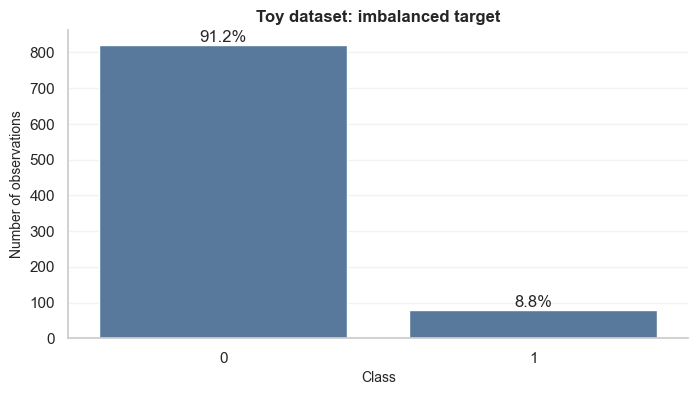

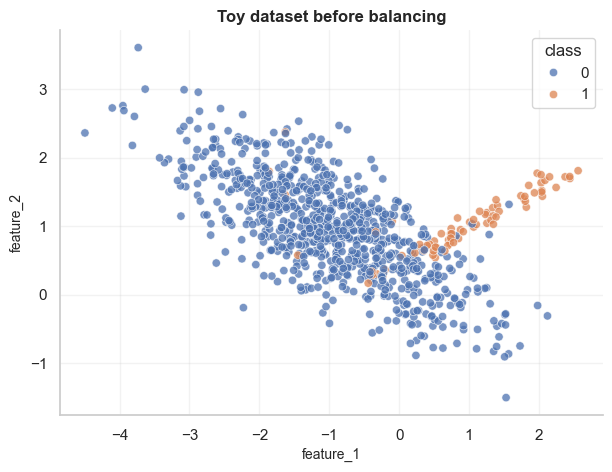

In [22]:
X_toy, y_toy = make_classification(
    n_samples=900,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    weights=[0.92, 0.08],
    class_sep=1.0,
    random_state=RANDOM_STATE,
)

display(class_balance_table(y_toy, "toy_target"))
plot_class_balance(y_toy, "Toy dataset: imbalanced target")
plot_2d_data(X_toy, y_toy, "Toy dataset before balancing")

### 3.1 Correct workflow: split first, balance only the training data

Balancing before the split can leak synthetic or duplicated information into the test set.  
The test set should remain close to the original business reality.

In [23]:
X_train_toy, X_test_toy, y_train_toy, y_test_toy = train_test_split(
    X_toy,
    y_toy,
    test_size=0.30,
    stratify=y_toy,
    random_state=RANDOM_STATE,
)

print("Training balance")
display(class_balance_table(y_train_toy, "target"))

print("Test balance")
display(class_balance_table(y_test_toy, "target"))

Training balance


,class,count,percent
0,0,575,91.27
1,1,55,8.73


Test balance


,class,count,percent
0,0,246,91.11
1,1,24,8.89


## 4. Main resampling methods on the toy dataset

The next cells show how each method changes the training data.

The purpose is not to make the dataset look perfectly beautiful. The purpose is to give the model a better opportunity to learn the minority class.

In [25]:
resampled_toy = {}

resampled_toy["Original training data"] = (X_train_toy, y_train_toy)
resampled_toy["Random undersampling"] = random_undersample(X_train_toy, y_train_toy, RANDOM_STATE)
resampled_toy["Random oversampling"] = random_oversample(X_train_toy, y_train_toy, RANDOM_STATE)
resampled_toy["Hybrid sampling"] = hybrid_sample(X_train_toy, y_train_toy, target_ratio=0.50, random_state=RANDOM_STATE)
resampled_toy["ROSE-style sampling"] = rose_style_sample(X_train_toy, y_train_toy, noise_scale=0.08, random_state=RANDOM_STATE)
resampled_toy["SMOTE"] = simple_smote(X_train_toy, y_train_toy, k_neighbors=5, random_state=RANDOM_STATE)
resampled_toy["ADASYN"] = simple_adasyn(X_train_toy, y_train_toy, k_neighbors=5, random_state=RANDOM_STATE)

for name, (_, y_res) in resampled_toy.items():
    print(name)
    display(class_balance_table(y_res))

Original training data


,class,count,percent
0,0,575,91.27
1,1,55,8.73


Random undersampling


,class,count,percent
0,0,55,50.0
1,1,55,50.0


Random oversampling


...

,class,count,percent
0,0,575,50.0
1,1,575,50.0


SMOTE


,class,count,percent
0,0,575,50.0
1,1,575,50.0


ADASYN


,class,count,percent
0,0,575,50.0
1,1,575,50.0


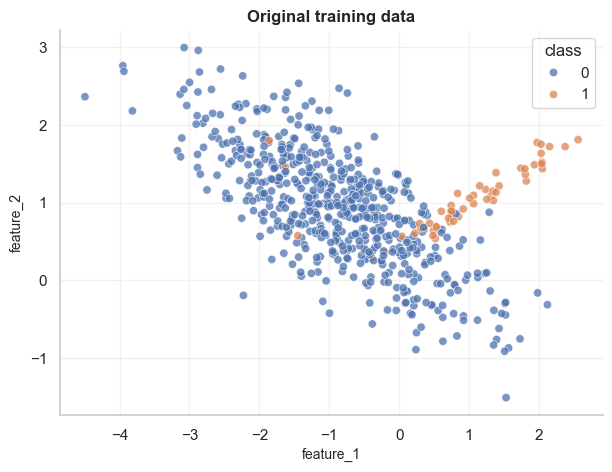

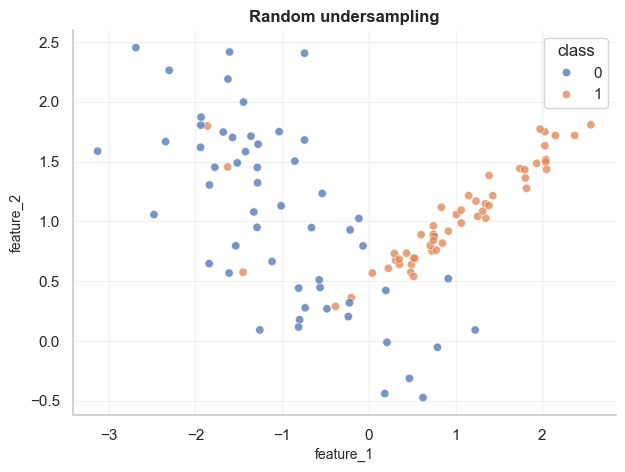

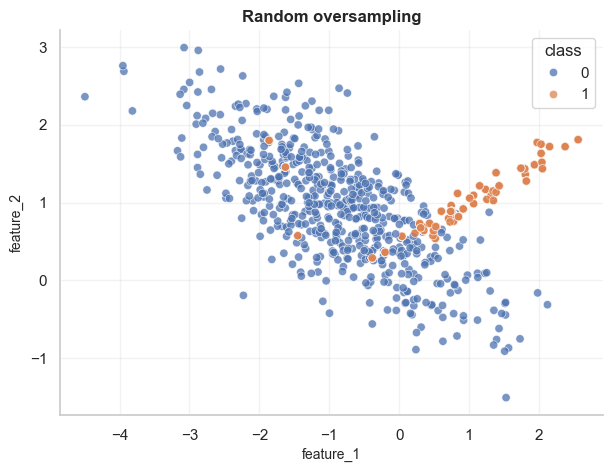

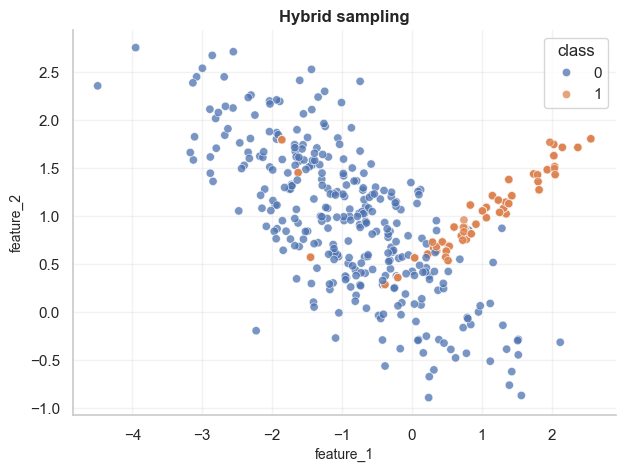

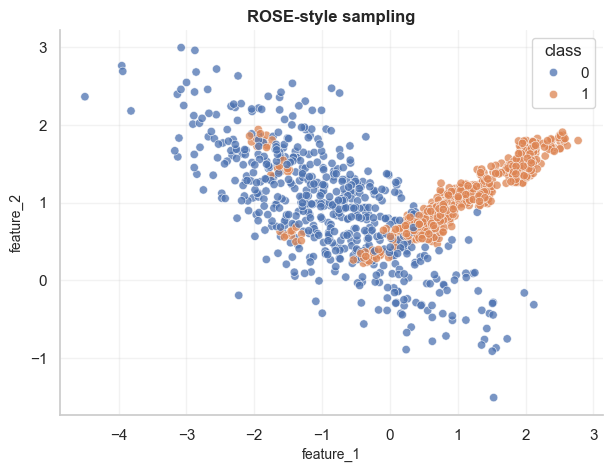

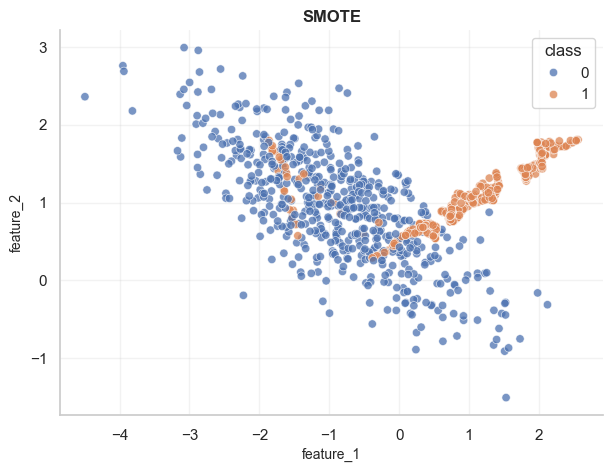

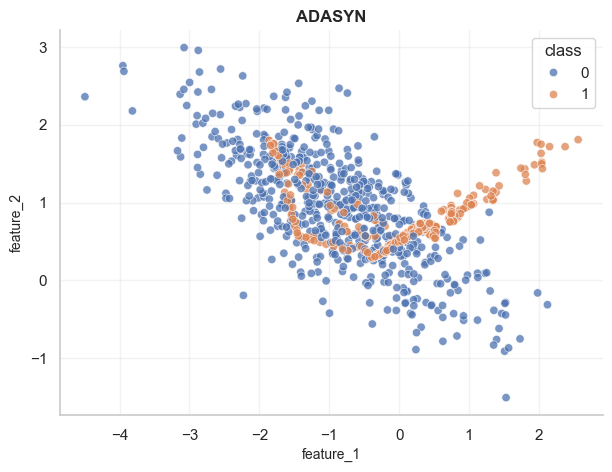

In [26]:
for name, (X_res, y_res) in resampled_toy.items():
    plot_2d_data(X_res, y_res, title=name)

### Interpretation

- **Undersampling** reduces majority examples. It is fast, but it may discard useful information.
- **Oversampling** duplicates minority examples. It keeps all data, but repeated rows can increase overfitting.
- **Hybrid sampling** combines both ideas and often provides a practical compromise.
- **ROSE-style sampling** creates smoothed synthetic examples around minority observations.
- **SMOTE** creates synthetic points between minority neighbors.
- **ADASYN** is similar to SMOTE but creates more synthetic points around harder minority regions.

## 5. Model comparison on the toy dataset

The model is trained on each resampled training dataset, but always evaluated on the original untouched test dataset.

This is the most important evaluation rule in this notebook.

In [8]:
toy_results = []

for name, (X_res, y_res) in resampled_toy.items():
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    result = evaluate_classifier(model, X_res, y_res, X_test_toy, y_test_toy, name)
    toy_results.append(result)

toy_metrics = metrics_frame(toy_results)
display(toy_metrics.sort_values("f1", ascending=False))

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Original training data,0.944,0.846,0.458,0.595,0.900
Hybrid sampling,0.900,0.459,0.708,0.557,0.900
Random oversampling,0.896,0.447,0.708,0.548,0.900
ROSE-style sampling,0.896,0.447,0.708,0.548,0.900
SMOTE,0.893,0.436,0.708,0.540,0.900
Random undersampling,0.878,0.395,0.708,0.507,0.902
ADASYN,0.789,0.261,0.750,0.387,0.901


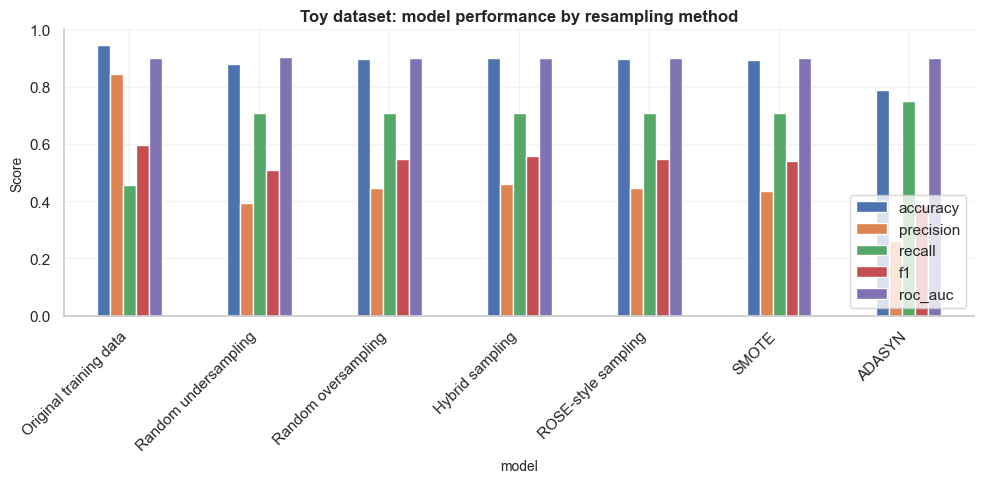

In [27]:
toy_metrics[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(10, 5))
plt.title("Toy dataset: model performance by resampling method")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Practical interpretation

In imbalanced classification, accuracy can look strong even when the model misses many minority cases.

For rare-event problems, recall and F1-score are often more informative:

- **Recall** answers: of the actual minority cases, how many did the model detect?
- **Precision** answers: of the cases flagged by the model, how many were really minority cases?
- **F1-score** balances precision and recall.
- **ROC AUC** summarizes ranking quality across thresholds.

## 6. Realistic dataset example: Breast Cancer dataset

This section uses a built-in scikit-learn dataset and intentionally creates a stronger imbalance.  
The workflow is the same as in a business case: inspect the target, split the data, balance the training data, fit models, and compare results.

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,high_risk
0,10.880,15.62,70.41,358.9,0.10070,0.10690,0.051150,0.015710,0.1861,0.06837,...,19.35,80.78,433.1,0.13320,0.38980,0.33650,0.07966,0.2581,0.10800,0
1,9.667,18.49,61.49,289.1,0.08946,0.06258,0.029480,0.015140,0.2238,0.06413,...,25.62,70.88,385.2,0.12340,0.15420,0.12770,0.06560,0.3174,0.08524,0
2,9.787,19.94,62.11,294.5,0.10240,0.05301,0.006829,0.007937,0.1350,0.06890,...,26.29,68.81,366.1,0.13160,0.09473,0.02049,0.02381,0.1934,0.08988,0
3,11.270,12.96,73.16,386.3,0.12370,0.11110,0.079000,0.055500,0.2018,0.06914,...,20.53,84.93,476.1,0.16100,0.24290,0.22470,0.13180,0.3343,0.09215,0
4,12.770,21.41,82.02,507.4,0.08749,0.06601,0.031120,0.028640,0.1694,0.06287,...,23.50,89.04,579.5,0.09388,0.08978,0.05186,0.04773,0.2179,0.06871,0


,class,count,percent
0,0,357,88.81
1,1,45,11.19


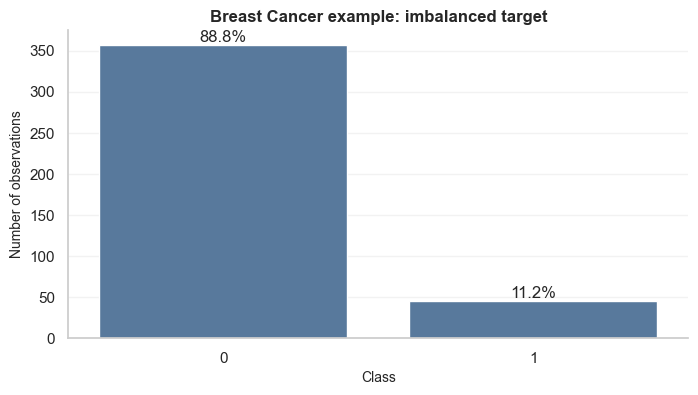

In [28]:
cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame.copy()

# In this dataset, target 0 = malignant and 1 = benign.
# To make the minority class easier to interpret, we create a binary target:
# high_risk = 1 for malignant, 0 for benign.
cancer_df["high_risk"] = (cancer_df["target"] == 0).astype(int)
cancer_df = cancer_df.drop(columns=["target"])

# Create stronger imbalance by keeping all low-risk cases and only part of the high-risk cases.
low_risk = cancer_df[cancer_df["high_risk"] == 0]
high_risk = cancer_df[cancer_df["high_risk"] == 1].sample(n=45, random_state=RANDOM_STATE)

imbalanced_cancer_df = pd.concat([low_risk, high_risk], ignore_index=True)
imbalanced_cancer_df = imbalanced_cancer_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

display(imbalanced_cancer_df.head())
display(class_balance_table(imbalanced_cancer_df["high_risk"], "high_risk"))
plot_class_balance(imbalanced_cancer_df["high_risk"], "Breast Cancer example: imbalanced target")

### 6.1 Prepare features and split data

The scaler is fitted only on the training data.  
This follows the same logic as balancing: the test set should represent unseen data.

In [30]:
X = imbalanced_cancer_df.drop(columns=["high_risk"])
y = imbalanced_cancer_df["high_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data")
display(class_balance_table(y_train, "high_risk"))

print("Test data")
display(class_balance_table(y_test, "high_risk"))

Training data


,class,count,percent
0,0,250,88.97
1,1,31,11.03


Test data


,class,count,percent
0,0,107,88.43
1,1,14,11.57


## 7. Apply balancing methods to the realistic dataset

Only the training data is resampled.

,class,count,percent,method
0,0,250,88.97,Original training data
1,1,31,11.03,Original training data
2,0,31,50.00,Random undersampling
3,1,31,50.00,Random undersampling
4,0,250,50.00,Random oversampling
5,1,250,50.00,Random oversampling
6,0,140,50.00,Hybrid sampling
7,1,140,50.00,Hybrid sampling
8,0,250,50.00,ROSE-style sampling
9,1,250,50.00,ROSE-style sampling


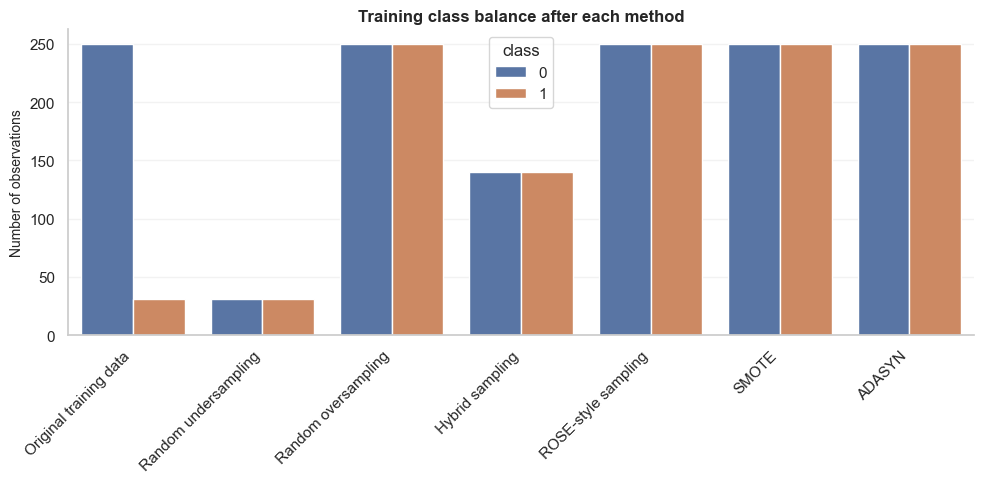

In [31]:
resampled_realistic = {
    "Original training data": (X_train_scaled, y_train.to_numpy()),
    "Random undersampling": random_undersample(X_train_scaled, y_train, RANDOM_STATE),
    "Random oversampling": random_oversample(X_train_scaled, y_train, RANDOM_STATE),
    "Hybrid sampling": hybrid_sample(X_train_scaled, y_train, target_ratio=0.50, random_state=RANDOM_STATE),
    "ROSE-style sampling": rose_style_sample(X_train_scaled, y_train, noise_scale=0.05, random_state=RANDOM_STATE),
    "SMOTE": simple_smote(X_train_scaled, y_train, k_neighbors=5, random_state=RANDOM_STATE),
    "ADASYN": simple_adasyn(X_train_scaled, y_train, k_neighbors=5, random_state=RANDOM_STATE),
}

balance_summary = []
for name, (_, y_res) in resampled_realistic.items():
    temp = class_balance_table(y_res)
    temp["method"] = name
    balance_summary.append(temp)

balance_summary_df = pd.concat(balance_summary, ignore_index=True)
display(balance_summary_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=balance_summary_df, x="method", y="count", hue="class")
plt.title("Training class balance after each method")
plt.xlabel("")
plt.ylabel("Number of observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Train and evaluate models

The test data remains untouched and imbalanced.  
This is intentional because the evaluation should reflect the original real-world distribution.

In [32]:
realistic_results = []

for name, (X_res, y_res) in resampled_realistic.items():
    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    result = evaluate_classifier(model, X_res, y_res, X_test_scaled, y_test, name)
    realistic_results.append(result)

realistic_metrics = metrics_frame(realistic_results)
display(realistic_metrics.sort_values("f1", ascending=False))

,accuracy,precision,recall,f1,roc_auc
model,,,,,
SMOTE,1.000,1.000,1.000,1.000,1.000
ROSE-style sampling,0.992,0.933,1.000,0.966,1.000
Random oversampling,0.992,0.933,1.000,0.966,1.000
ADASYN,0.992,0.933,1.000,0.966,1.000
Original training data,0.992,1.000,0.929,0.963,1.000
Hybrid sampling,0.975,0.824,1.000,0.903,0.999
Random undersampling,0.975,0.867,0.929,0.897,0.989


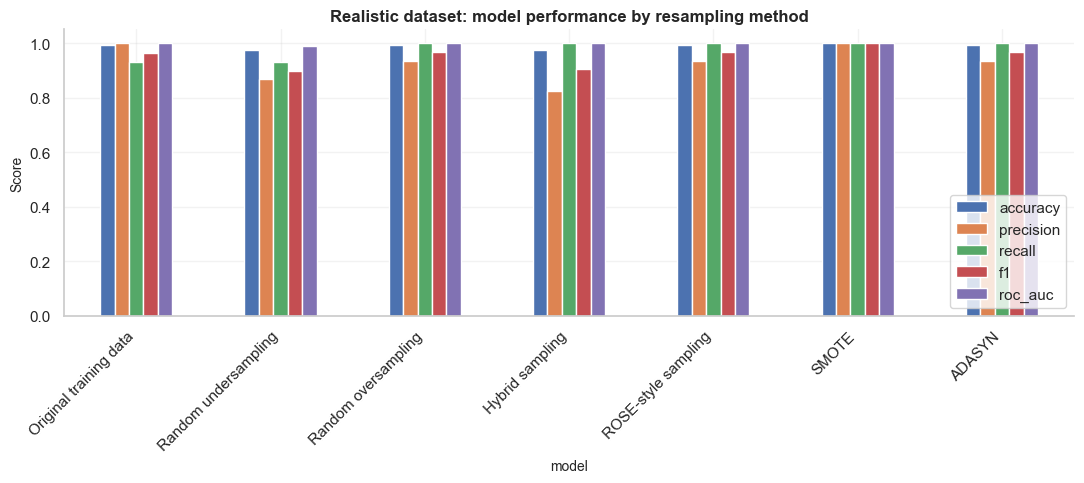

In [33]:
realistic_metrics[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(11, 5))
plt.title("Realistic dataset: model performance by resampling method")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion matrix comparison

The confusion matrix shows how the model is wrong, not only whether it is wrong.

For a rare high-risk class, false negatives are often the most important error because they represent missed high-risk cases.

In [15]:
for result in realistic_results:
    print_evaluation(result)
    print()

Original training data
----------------------
Accuracy : 0.992
Precision: 1.000
Recall   : 0.929
F1-score : 0.963
ROC AUC  : 1.000

Confusion matrix:
[[107   0]
 [  1  13]]

Random undersampling
--------------------
Accuracy : 0.975
Precision: 0.867
Recall   : 0.929
F1-score : 0.897
ROC AUC  : 0.989

Confusion matrix:
[[105   2]
 [  1  13]]

Random oversampling
-------------------
Accuracy : 0.992
Precision: 0.933
Recall   : 1.000
F1-score : 0.966
ROC AUC  : 1.000

Confusion matrix:
[[106   1]
 [  0  14]]

Hybrid sampling
---------------
Accuracy : 0.975
Precision: 0.824
Recall   : 1.000
F1-score : 0.903
ROC AUC  : 0.999

Confusion matrix:
[[104   3]
 [  0  14]]

ROSE-style sampling
-------------------
Accuracy : 0.992
Precision: 0.933
Recall   : 1.000
F1-score : 0.966
ROC AUC  : 1.000

Confusion matrix:
[[106   1]
 [  0  14]]

SMOTE
-----
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC AUC  : 1.000

Confusion matrix:
[[107   0]
 [  0  14]]

ADASYN
------
Accura

## 9. Threshold interpretation

Balancing changes how the model learns.  
Another practical lever is the probability threshold used to convert predicted probabilities into class labels.

The default threshold is usually 0.50. In rare-event problems, a lower threshold may increase recall, but it may also increase false positives.

,threshold,accuracy,precision,recall,f1,false_negatives,false_positives
0,0.2,0.959,0.737,1.000,0.848,0,5
1,0.3,0.992,0.933,1.000,0.966,0,1
2,0.4,0.992,0.933,1.000,0.966,0,1
3,0.5,1.000,1.000,1.000,1.000,0,0
4,0.6,0.992,1.000,0.929,0.963,1,0


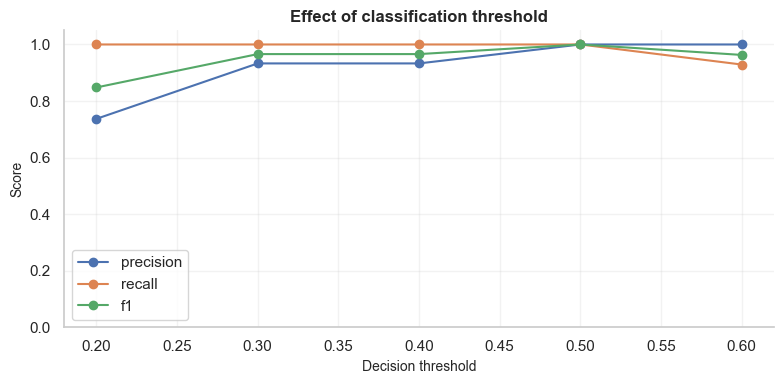

In [34]:
baseline_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
X_smote, y_smote = resampled_realistic["SMOTE"]
baseline_model.fit(X_smote, y_smote)

probabilities = baseline_model.predict_proba(X_test_scaled)[:, 1]

threshold_rows = []
for threshold in [0.20, 0.30, 0.40, 0.50, 0.60]:
    pred = (probabilities >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "false_negatives": confusion_matrix(y_test, pred)[1, 0],
        "false_positives": confusion_matrix(y_test, pred)[0, 1],
    })

threshold_df = pd.DataFrame(threshold_rows).round(3)
display(threshold_df)

plt.figure(figsize=(8, 4))
for metric in ["precision", "recall", "f1"]:
    plt.plot(threshold_df["threshold"], threshold_df[metric], marker="o", label=metric)
plt.title("Effect of classification threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

### Business interpretation

A lower threshold can be useful when missing a minority case is very costly.  
A higher threshold can be useful when false alarms are expensive.

Examples:

- fraud detection: higher recall may be preferred if missed fraud is very costly
- medical screening: false negatives may be more dangerous than false positives
- customer targeting: too many false positives may waste campaign budget

## 10. Synthetic fraud dataset from the generator script

The separate file `generate_balancing_resampling_dataset.py` creates a reusable imbalanced dataset.

If the CSV is already present, this notebook loads it. Otherwise, it generates the dataset directly.

,transaction_id,transaction_amount,transaction_frequency_7d,account_age_days,distance_from_home_km,time_since_last_transaction_hours,failed_login_attempts_24h,channel,country,fraud
0,T001448,59.39,4,499.50,20.43,0.51,0,card,DE,0
1,T001115,27.28,2,846.48,5.67,11.52,0,online,DE,0
2,T001065,18.09,3,840.91,3.19,5.19,0,mobile,DE,0
3,T002288,90.25,4,547.67,3.85,10.03,0,mobile,FR,0
4,T001538,10.20,2,494.19,4.08,3.82,0,mobile,DE,0


,class,count,percent
0,0,2413,96.52
1,1,87,3.48


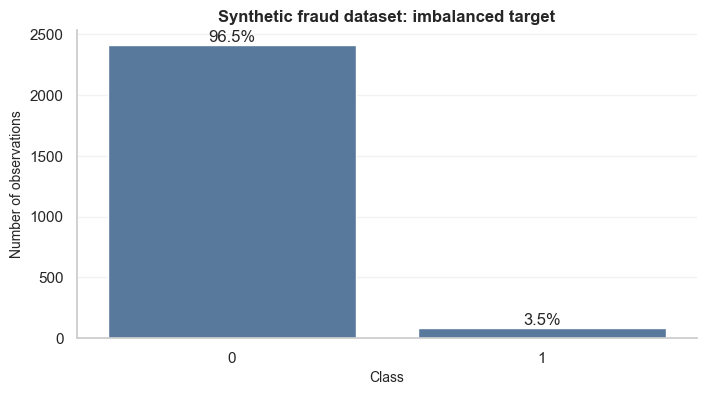

In [17]:
generator_path = Path("generate_balancing_resampling_dataset.py")
csv_path = Path("synthetic_balancing_resampling_dataset.csv")

if csv_path.exists():
    fraud_df = pd.read_csv(csv_path)
else:
    try:
        from generate_balancing_resampling_dataset import generate_dataset
        fraud_df = generate_dataset()
    except ImportError:
        # Fallback if the notebook is run without the separate script.
        rng = np.random.default_rng(RANDOM_STATE)
        X_tmp, y_tmp = make_classification(
            n_samples=2500,
            n_features=6,
            n_informative=4,
            n_redundant=1,
            weights=[0.965, 0.035],
            random_state=RANDOM_STATE,
        )
        fraud_df = pd.DataFrame(X_tmp, columns=[f"feature_{i}" for i in range(1, 7)])
        fraud_df["fraud"] = y_tmp

display(fraud_df.head())
display(class_balance_table(fraud_df["fraud"], "fraud"))
plot_class_balance(fraud_df["fraud"], "Synthetic fraud dataset: imbalanced target")

### Prepare and model the synthetic fraud dataset

Categorical variables are converted with one-hot encoding.  
The same train/test rule is applied: split first, balance only training data.

In [18]:
fraud_model_df = fraud_df.drop(columns=[col for col in ["transaction_id"] if col in fraud_df.columns])
fraud_model_df = pd.get_dummies(fraud_model_df, drop_first=True)

X_fraud = fraud_model_df.drop(columns=["fraud"])
y_fraud = fraud_model_df["fraud"]

X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.30,
    stratify=y_fraud,
    random_state=RANDOM_STATE,
)

scaler_fraud = StandardScaler()
X_train_fraud_scaled = scaler_fraud.fit_transform(X_train_fraud)
X_test_fraud_scaled = scaler_fraud.transform(X_test_fraud)

fraud_resampled = {
    "Original training data": (X_train_fraud_scaled, y_train_fraud.to_numpy()),
    "Random undersampling": random_undersample(X_train_fraud_scaled, y_train_fraud, RANDOM_STATE),
    "Random oversampling": random_oversample(X_train_fraud_scaled, y_train_fraud, RANDOM_STATE),
    "Hybrid sampling": hybrid_sample(X_train_fraud_scaled, y_train_fraud, target_ratio=0.50, random_state=RANDOM_STATE),
    "SMOTE": simple_smote(X_train_fraud_scaled, y_train_fraud, k_neighbors=5, random_state=RANDOM_STATE),
    "ADASYN": simple_adasyn(X_train_fraud_scaled, y_train_fraud, k_neighbors=5, random_state=RANDOM_STATE),
}

fraud_results = []
for name, (X_res, y_res) in fraud_resampled.items():
    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    fraud_results.append(evaluate_classifier(model, X_res, y_res, X_test_fraud_scaled, y_test_fraud, name))

fraud_metrics = metrics_frame(fraud_results)
display(fraud_metrics.sort_values("f1", ascending=False))

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Original training data,0.985,0.826,0.731,0.776,0.978
SMOTE,0.977,0.629,0.846,0.721,0.978
Hybrid sampling,0.973,0.579,0.846,0.688,0.978
Random oversampling,0.973,0.579,0.846,0.688,0.979
ADASYN,0.973,0.583,0.808,0.677,0.979
Random undersampling,0.969,0.537,0.846,0.657,0.975


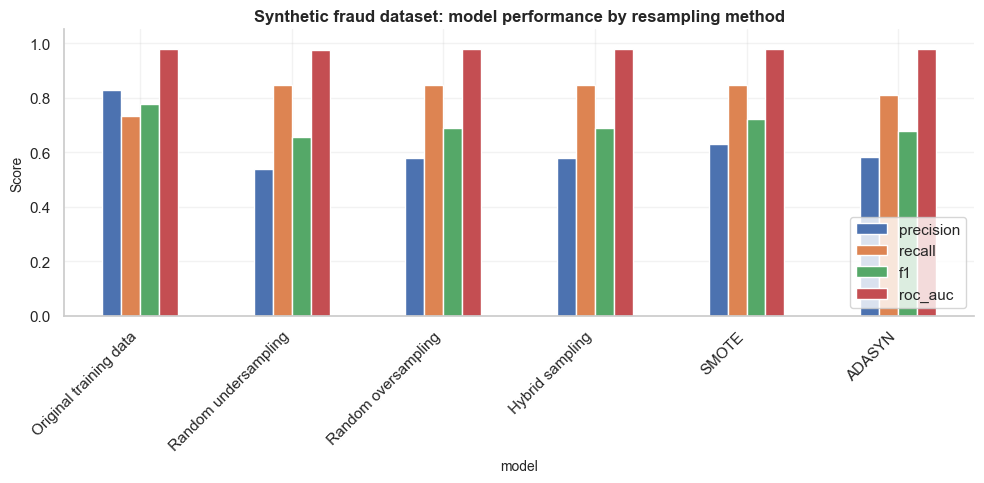

In [19]:
fraud_metrics[["precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(10, 5))
plt.title("Synthetic fraud dataset: model performance by resampling method")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. Common mistakes and practical pitfalls

* Mistake 1: balancing before train/test split
This can create leakage. Duplicated or synthetic examples may influence both training and testing.

* Mistake 2: evaluating only with accuracy
High accuracy can hide poor minority-class detection.

* Mistake 3: assuming 50/50 is always best
A fully balanced training set is a useful starting point, but not always the best business decision.

* Mistake 4: using synthetic methods without checking the data
SMOTE and ADASYN can create unrealistic points when classes overlap strongly or when minority examples contain noise.

* Mistake 5: ignoring the cost of errors
False positives and false negatives rarely have the same business impact.